In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')
print('done')

done


In [2]:
temp_df = pd.read_csv('laptopPrice.csv')
temp_df.head()

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
0,ASUS,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,34649,2 stars,3,0
1,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,38999,3 stars,65,5
2,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,39999,3 stars,8,1
3,ASUS,Intel,Core i5,10th,8 GB,DDR4,512 GB,0 GB,Windows,32-bit,2 GB,Casual,No warranty,No,No,69990,3 stars,0,0
4,ASUS,Intel,Celeron Dual,Not Available,4 GB,DDR4,0 GB,512 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,26990,3 stars,0,0


In [3]:
temp_df.shape

(823, 19)

In [4]:
selected_columns = ['brand', 'processor_brand', 'processor_name', 'processor_gnrtn',
                    'ram_gb', 'ram_type', 'ssd', 'hdd', 'os', 'os_bit', 'graphic_card_gb',
                    'weight', 'warranty', 'Touchscreen', 'Price']
df = temp_df[selected_columns]

In [5]:
df.head()


,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,Price
0,ASUS,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,34649
1,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,38999
2,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,39999
3,ASUS,Intel,Core i5,10th,8 GB,DDR4,512 GB,0 GB,Windows,32-bit,2 GB,Casual,No warranty,No,69990
4,ASUS,Intel,Celeron Dual,Not Available,4 GB,DDR4,0 GB,512 GB,Windows,64-bit,0 GB,Casual,No warranty,No,26990


In [6]:
col = ['brand', 'processor_brand', 'processor_name', 'processor_gnrtn',
                    'ram_gb', 'ram_type', 'ssd', 'hdd', 'os', 'os_bit', 'graphic_card_gb',
                    'weight', 'warranty', 'Touchscreen']
for i,j in enumerate(col):
    print(f"{i+1}. Unique Values in {j}: ",df[j].unique())
    print(f"{i+1}. Number of unique Values -->",df[j].nunique(),end="\n"*2)

1. Unique Values in brand:  ['ASUS' 'Lenovo' 'acer' 'Avita' 'HP' 'DELL' 'MSI' 'APPLE']
1. Number of unique Values --> 8

2. Unique Values in processor_brand:  ['Intel' 'AMD' 'M1']
2. Number of unique Values --> 3

3. Unique Values in processor_name:  ['Core i3' 'Core i5' 'Celeron Dual' 'Ryzen 5' 'Core i7' 'Core i9' 'M1'
 'Pentium Quad' 'Ryzen 3' 'Ryzen 7' 'Ryzen 9']
3. Number of unique Values --> 11

4. Unique Values in processor_gnrtn:  ['10th' 'Not Available' '11th' '7th' '8th' '9th' '4th' '12th']
4. Number of unique Values --> 8

5. Unique Values in ram_gb:  ['4 GB' '8 GB' '16 GB' '32 GB']
5. Number of unique Values --> 4

6. Unique Values in ram_type:  ['DDR4' 'LPDDR4' 'LPDDR4X' 'DDR5' 'DDR3' 'LPDDR3']
6. Number of unique Values --> 6

7. Unique Values in ssd:  ['0 GB' '512 GB' '256 GB' '128 GB' '1024 GB' '2048 GB' '3072 GB']
7. Number of unique Values --> 7

8. Unique Values in hdd:  ['1024 GB' '0 GB' '512 GB' '2048 GB']
8. Number of unique Values --> 4

9. Unique Values in os:  [

In [7]:
df.isnull().sum()

brand              0
processor_brand    0
processor_name     0
processor_gnrtn    0
ram_gb             0
ram_type           0
ssd                0
hdd                0
os                 0
os_bit             0
graphic_card_gb    0
weight             0
warranty           0
Touchscreen        0
Price              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(41)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 823 entries, 0 to 822
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   brand            823 non-null    object
 1   processor_brand  823 non-null    object
 2   processor_name   823 non-null    object
 3   processor_gnrtn  823 non-null    object
 4   ram_gb           823 non-null    object
 5   ram_type         823 non-null    object
 6   ssd              823 non-null    object
 7   hdd              823 non-null    object
 8   os               823 non-null    object
 9   os_bit           823 non-null    object
 10  graphic_card_gb  823 non-null    object
 11  weight           823 non-null    object
 12  warranty         823 non-null    object
 13  Touchscreen      823 non-null    object
 14  Price            823 non-null    int64 
dtypes: int64(1), object(14)
memory usage: 96.6+ KB


# Data preprocessing

In [10]:
df['processor_gnrtn'] = df['processor_gnrtn'].str.replace('th','')
df['ram_gb'] = df['ram_gb'].str.replace('GB','')
df['ssd'] = df['ssd'].str.replace('GB','')
df['hdd'] = df['hdd'].str.replace('GB','')
df['os_bit'] = df['os_bit'].str.replace('-bit','')
df['graphic_card_gb'] = df['graphic_card_gb'].str.replace('GB','')

In [11]:
# Converting No warranty to 0
df['warranty'] = df['warranty'].apply(lambda x : 0 if x == 'No warranty' else x )
df['warranty'] = df['warranty'].str.split(' ').str[0]
df['warranty'] = df['warranty'].fillna(0)
df['warranty'] = df['warranty'].astype('int32')

In [12]:
df['ram_gb'] = df['ram_gb'].astype('int32')
df['ssd'] = df['ssd'].astype('int32')
df['hdd'] = df['hdd'].astype('int32')
df['os_bit'] = df['os_bit'].astype('int32')
df['graphic_card_gb'] = df['graphic_card_gb'].astype('int32')

In [13]:
df['processor_gnrtn'] = df['processor_gnrtn'].apply(lambda x : 0 if x == 'Not Available' else x )
median_value = df['processor_gnrtn'].median()
df['processor_gnrtn'] = df['processor_gnrtn'].replace(0,median_value).astype('int32')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 823 entries, 0 to 822
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   brand            823 non-null    object
 1   processor_brand  823 non-null    object
 2   processor_name   823 non-null    object
 3   processor_gnrtn  823 non-null    int32 
 4   ram_gb           823 non-null    int32 
 5   ram_type         823 non-null    object
 6   ssd              823 non-null    int32 
 7   hdd              823 non-null    int32 
 8   os               823 non-null    object
 9   os_bit           823 non-null    int32 
 10  graphic_card_gb  823 non-null    int32 
 11  weight           823 non-null    object
 12  warranty         823 non-null    int32 
 13  Touchscreen      823 non-null    object
 14  Price            823 non-null    int64 
dtypes: int32(7), int64(1), object(7)
memory usage: 74.1+ KB


In [15]:
df.describe()

,processor_gnrtn,ram_gb,ssd,hdd,os_bit,graphic_card_gb,warranty,Price
count,823.000000,823.000000,823.000000,823.000000,823.000000,823.000000,823.000000,823.000000
mean,10.266100,8.680437,452.121507,227.071689,59.761847,1.190765,0.721750,76745.177400
std,0.836169,4.372408,316.662592,413.105282,10.853667,2.026902,0.593231,45101.790525
min,4.000000,4.000000,0.000000,0.000000,32.000000,0.000000,0.000000,16990.000000
25%,10.000000,4.000000,256.000000,0.000000,64.000000,0.000000,0.000000,46095.000000
50%,10.000000,8.000000,512.000000,0.000000,64.000000,0.000000,1.000000,64990.000000
75%,11.000000,8.000000,512.000000,0.000000,64.000000,2.000000,1.000000,89636.000000
max,12.000000,32.000000,3072.000000,2048.000000,64.000000,8.000000,3.000000,441990.000000


# Data visualization (EDA)

<Axes: xlabel='Price', ylabel='Count'>

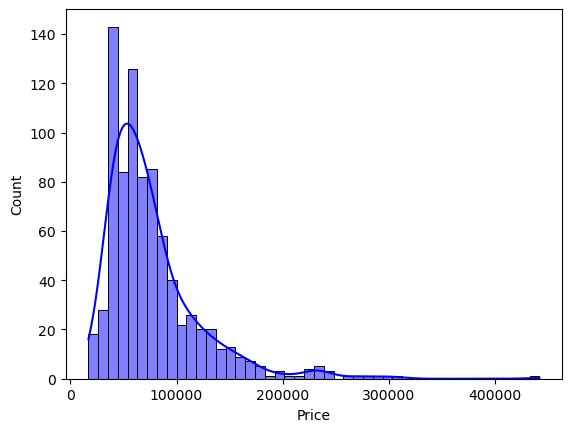

In [16]:
sns.histplot(df['Price'],color='blue',kde=True)

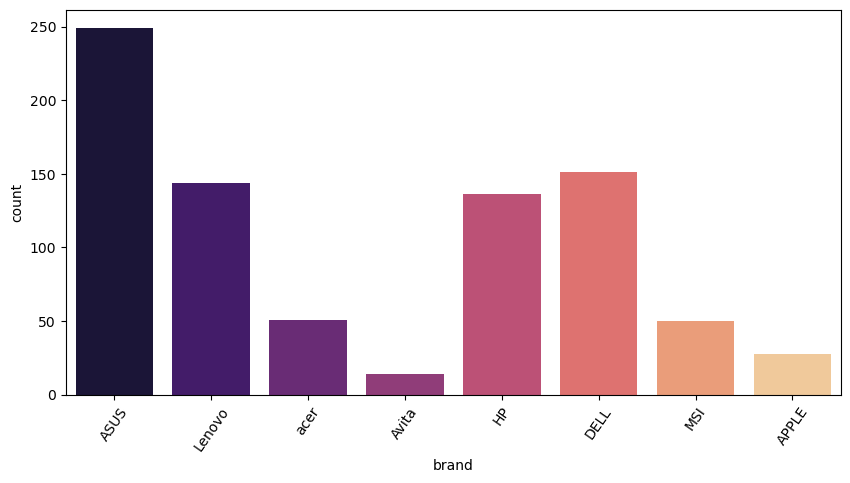

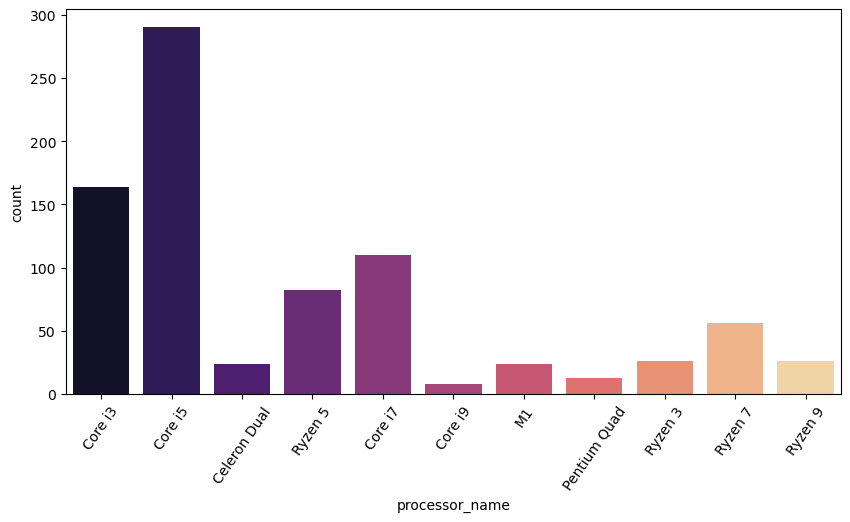

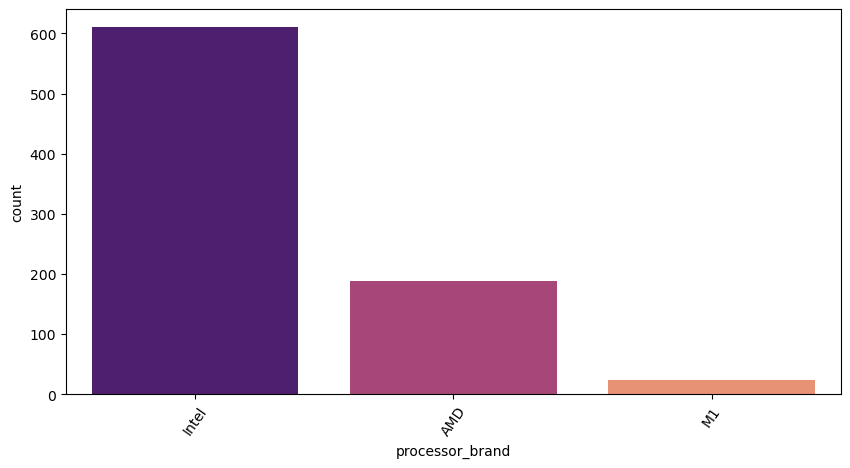

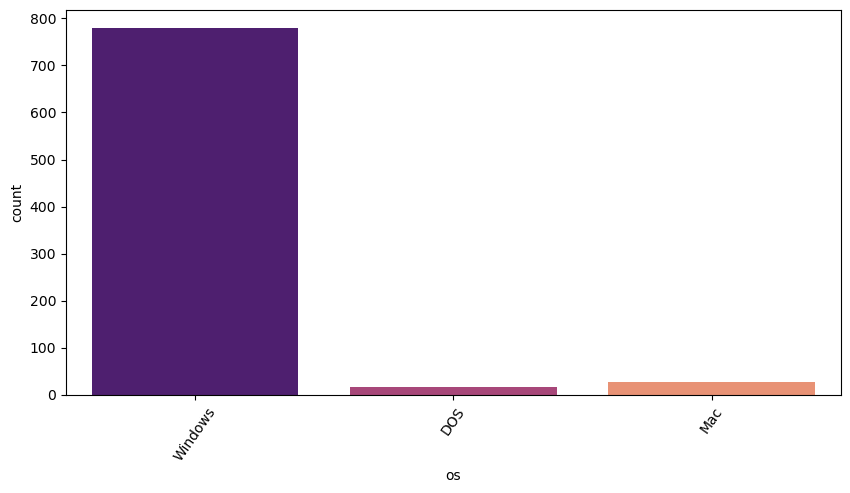

In [17]:
col = ['brand','processor_name','processor_brand','os']

for i in col:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df,x = df[i],palette="magma")
    plt.xticks(rotation=55)
    plt.show()

In [18]:
df.head(1)

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,Price
0,ASUS,Intel,Core i3,10,4,DDR4,0,1024,Windows,64,0,Casual,0,No,34649


<Axes: xlabel='Touchscreen', ylabel='Price'>

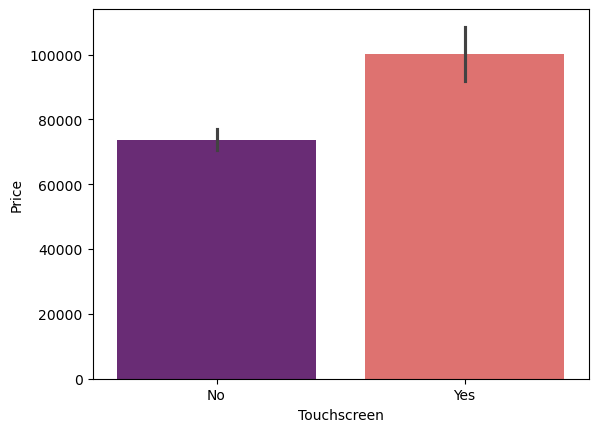

In [19]:
sns.barplot(data=df , x='Touchscreen',y='Price',palette='magma')

<Axes: xlabel='os_bit', ylabel='Price'>

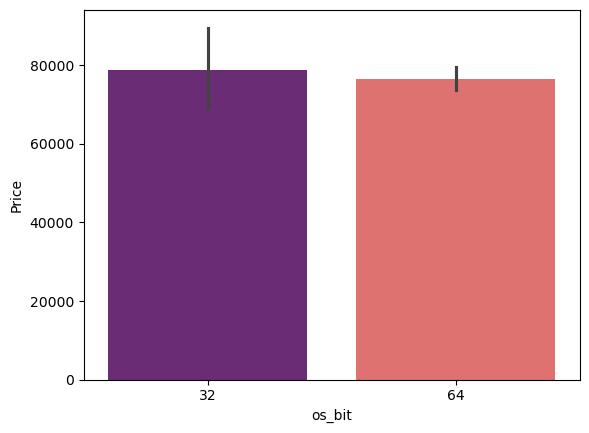

In [20]:
sns.barplot(data=df , x='os_bit',y='Price',palette='magma')

<Axes: xlabel='processor_gnrtn', ylabel='Price'>

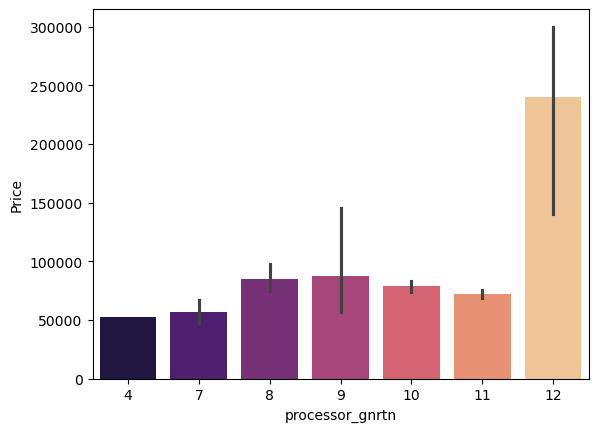

In [21]:
sns.barplot(data=df , x='processor_gnrtn',y='Price',palette='magma')

<Axes: xlabel='warranty', ylabel='Price'>

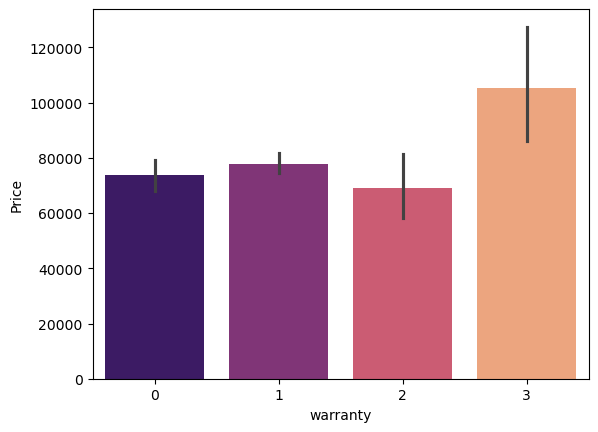

In [22]:
sns.barplot(x = df['warranty'], y= df['Price'],palette='magma')

<Axes: >

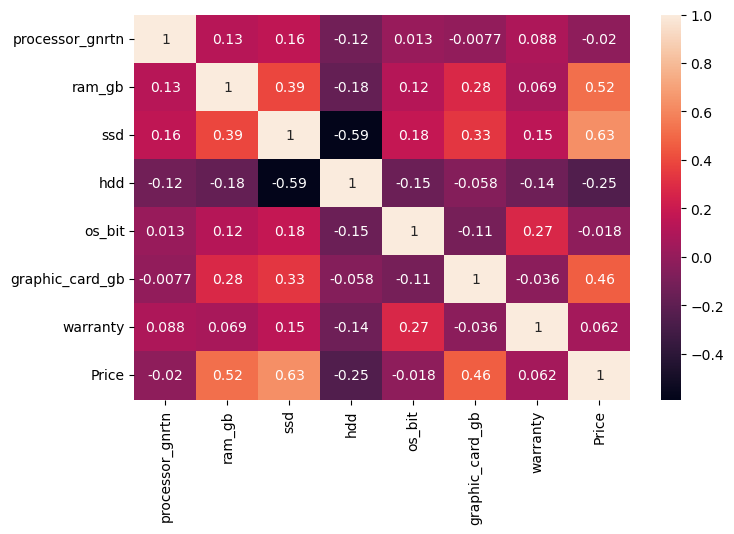

In [23]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [24]:
df.corr(numeric_only=True)['Price']

processor_gnrtn   -0.020151
ram_gb             0.518323
ssd                0.628272
hdd               -0.252699
os_bit            -0.018458
graphic_card_gb    0.459986
warranty           0.061840
Price              1.000000
Name: Price, dtype: float64

<Axes: xlabel='brand', ylabel='Price'>

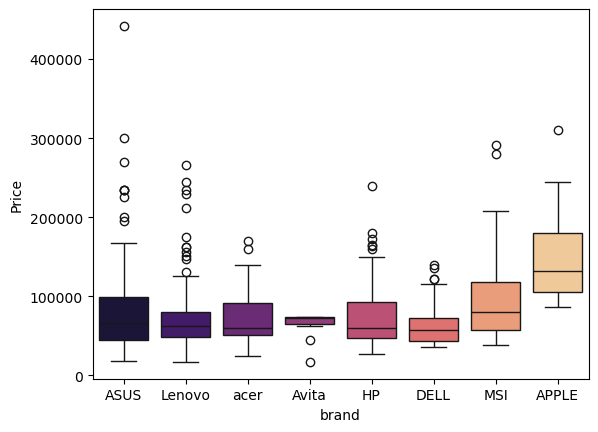

In [25]:
sns.boxplot(x="brand", y="Price", data=df,palette='magma')

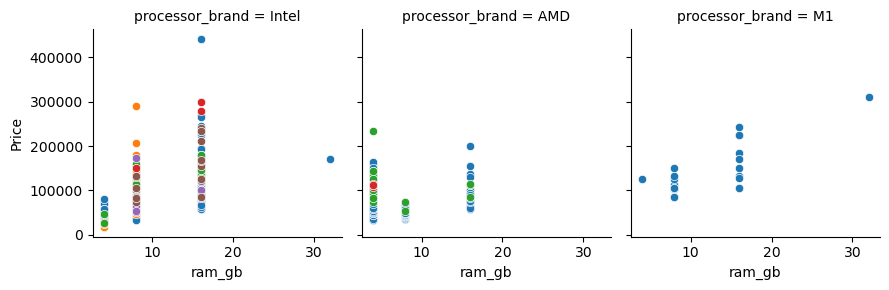

In [26]:
sns.FacetGrid(df, col="processor_brand", hue="ram_type").map(sns.scatterplot, "ram_gb", "Price")

<Axes: xlabel='os', ylabel='Price'>

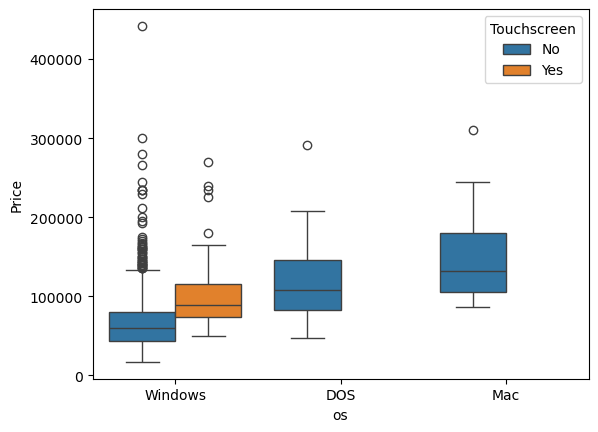

In [27]:
sns.boxplot(x="os", y="Price", hue="Touchscreen", data=df)

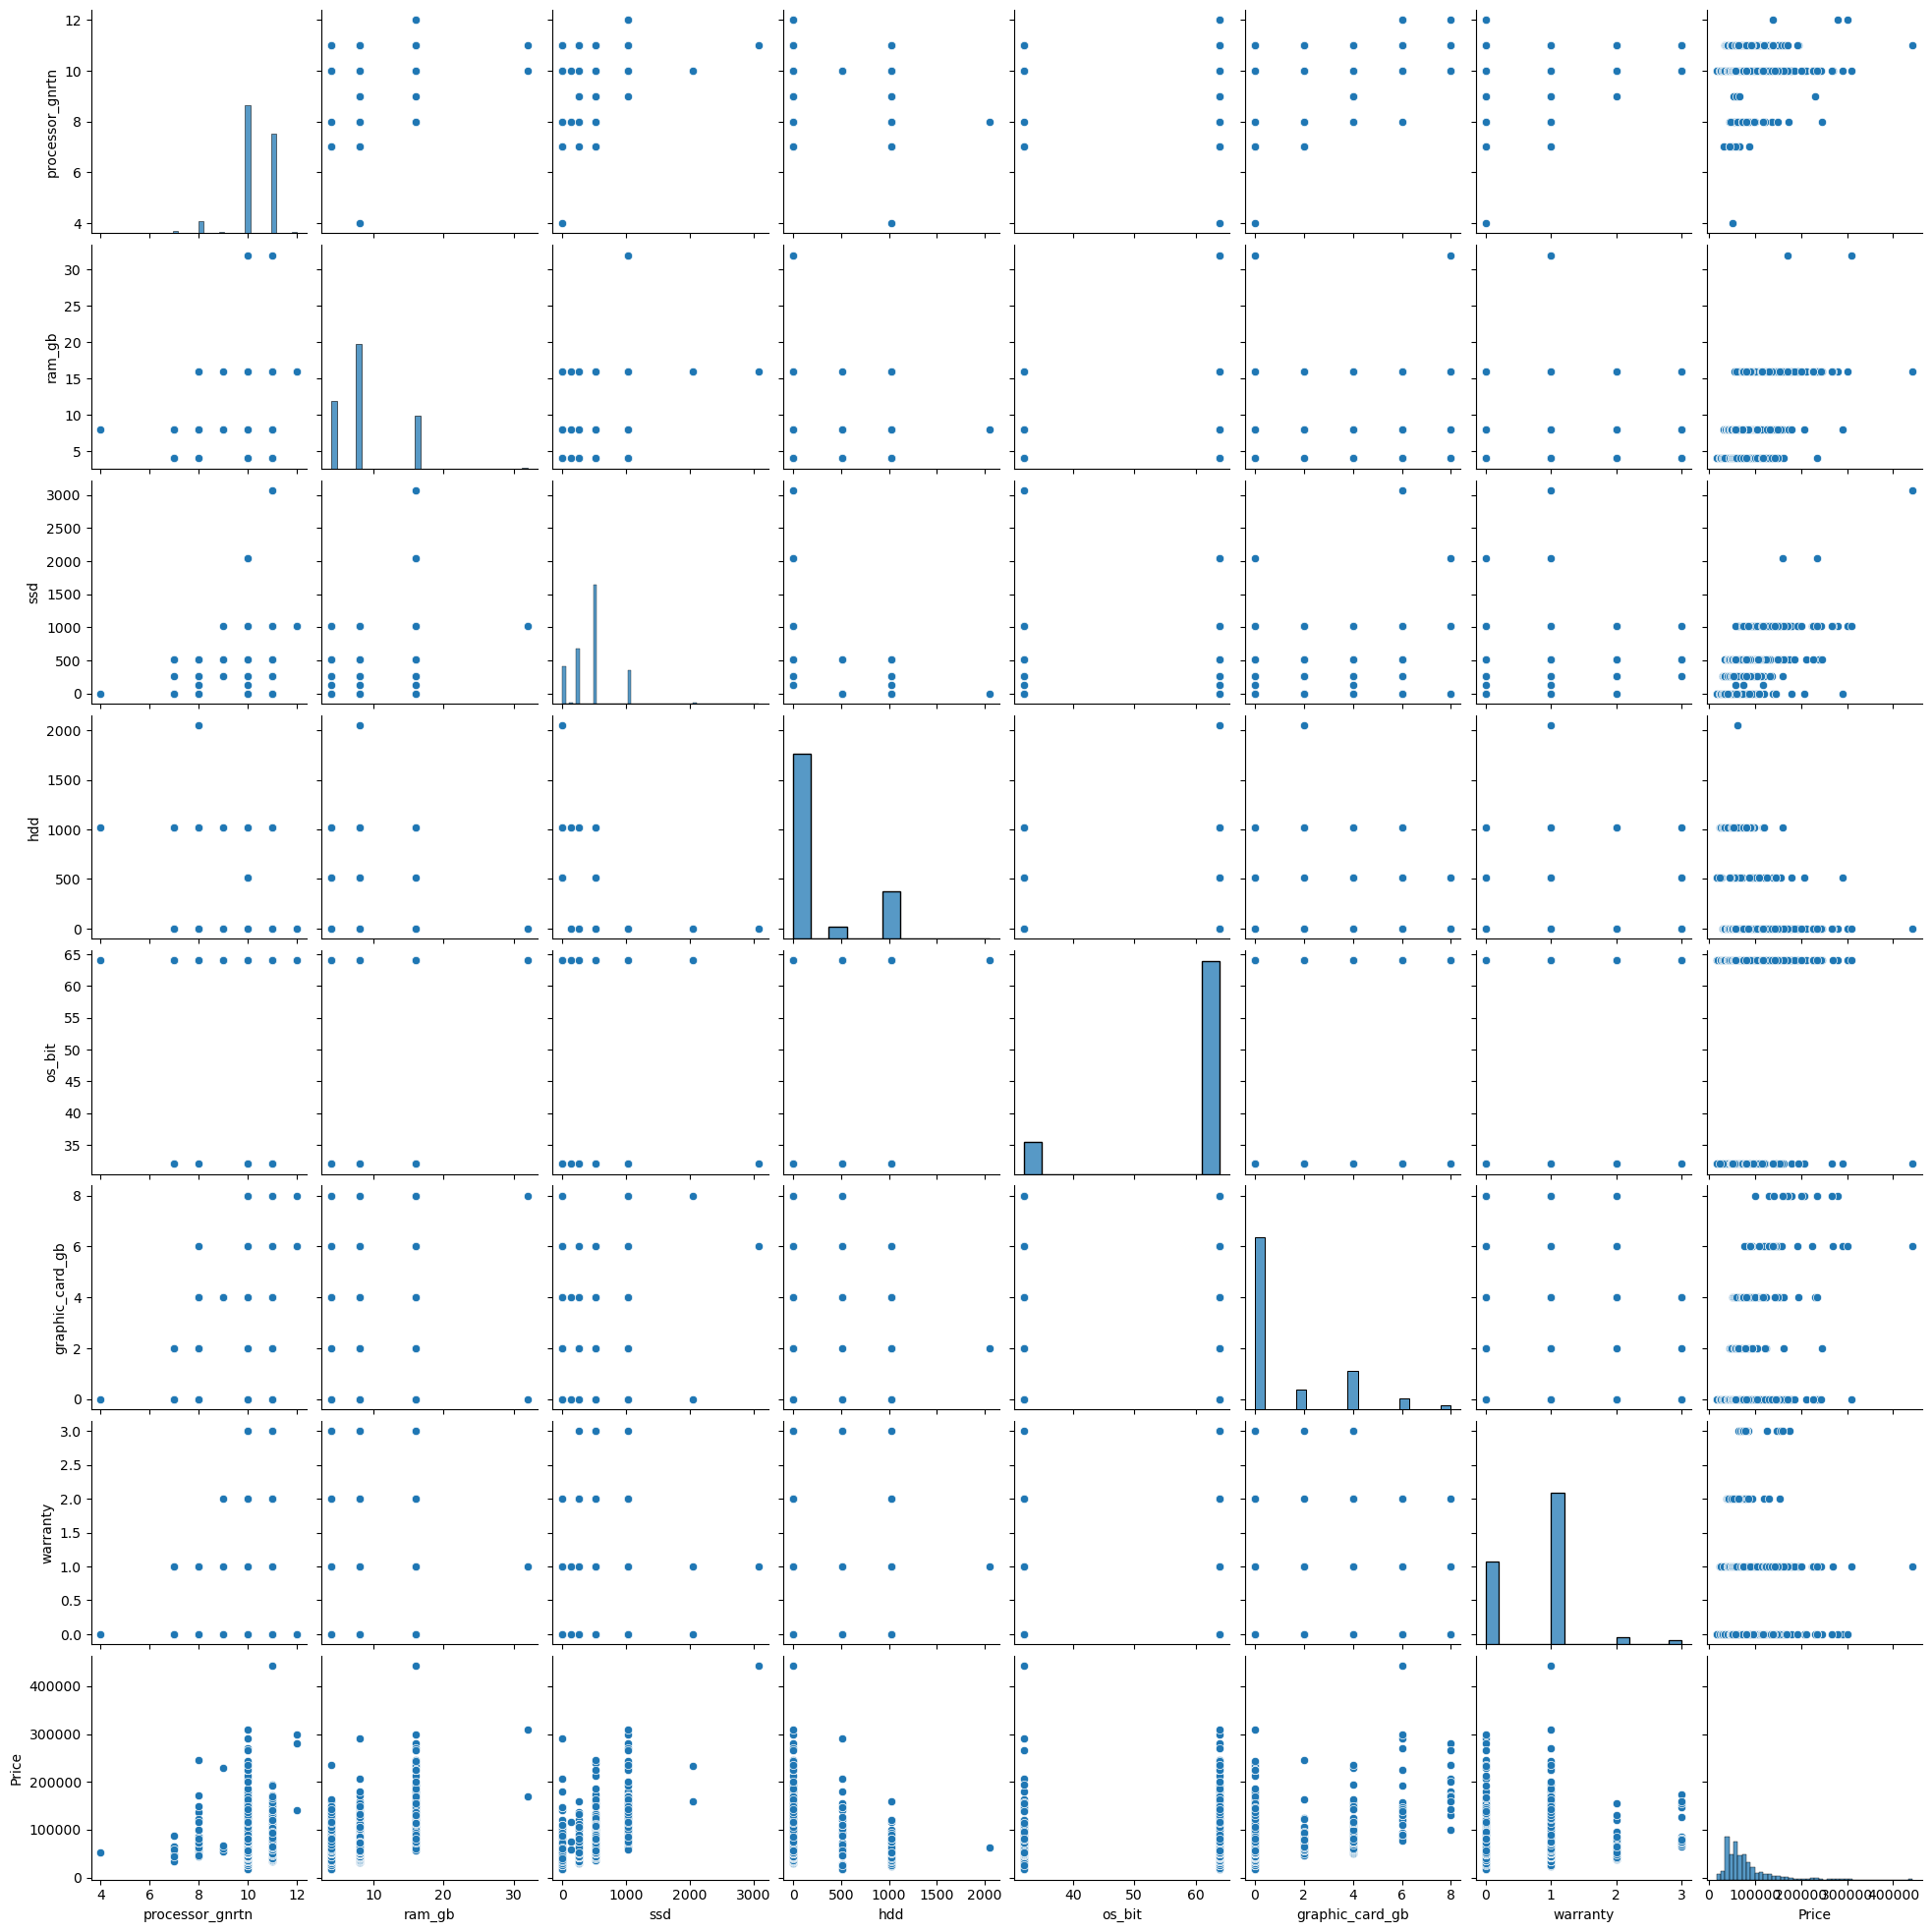

In [28]:
sns.pairplot(df)

<Axes: xlabel='Price', ylabel='Count'>

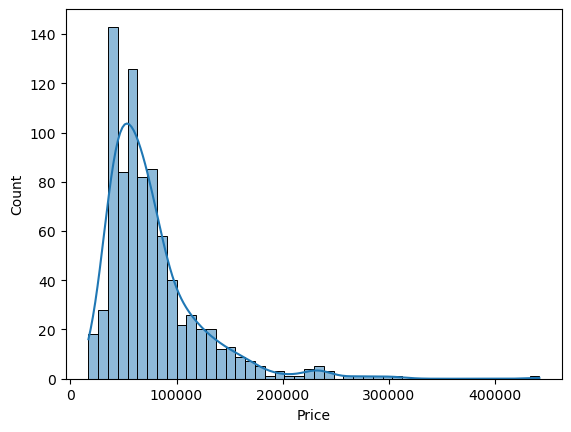

In [29]:
sns.histplot(df['Price'],kde=True)

# Model Building

In [30]:
X = df.drop(columns=['Price'])
y = df['Price']

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn import metrics
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn import tree

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

In [33]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(658, 14) (165, 14) (658,) (165,)


# LinearRegression

In [34]:
encoding = ColumnTransformer(transformers=[
    ('coltrf', StandardScaler(),[3, 4, 6, 7, 9, 10, 12]),
    ('coltrf1', OneHotEncoder(sparse_output=False,drop='first'),[0, 1, 2, 5, 8, 11, 13])
],remainder='passthrough')

lr = LinearRegression()

pipe = Pipeline([
    ('encoding',encoding),
    ('lr',lr)
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

print('R2 score:',metrics.r2_score(y_test,y_pred))
print('MAE:',metrics.mean_absolute_error(y_test,y_pred))

R2 score: 0.6639503684509553
MAE: 14654.884146695465


In [35]:
df.head(1)

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,Price
0,ASUS,Intel,Core i3,10,4,DDR4,0,1024,Windows,64,0,Casual,0,No,34649


# Lasso

In [36]:
encoding = ColumnTransformer(transformers=[
    ('coltrf', StandardScaler(),[3, 4, 6, 7, 9, 10, 12]),
    ('coltrf1', OneHotEncoder(sparse_output=False,drop='first'),[0, 1, 2, 5, 8, 11, 13])
],remainder='passthrough')

lasso = Lasso(alpha=0.001)

pipe = Pipeline([
    ('encoding',encoding),
    ('lesso',lasso)
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

print('R2 score:',metrics.r2_score(y_test,y_pred))
print('MAE:',metrics.mean_absolute_error(y_test,y_pred))

R2 score: 0.6663373332934962
MAE: 14531.58181385792


### Model performing littel of because the price column has right skewed distribution
- we can use Log transformation
- Laptop prices are skewed (many cheap laptops, few very expensive ones).
- Log makes the distribution more symmetric, which linear regression models handle better.

<Axes: xlabel='Price', ylabel='Count'>

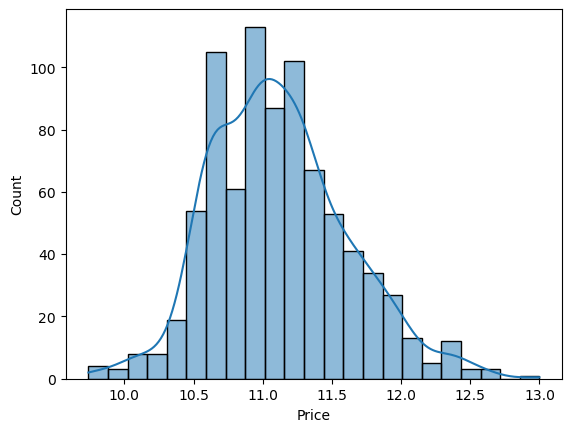

In [37]:
sns.histplot(np.log(df['Price']),kde=True)

In [38]:
X = df.drop(columns=['Price'])
y = np.log(df['Price'])

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Linear Regression

In [40]:
encoding = ColumnTransformer(transformers=[
    ('coltf',OneHotEncoder(sparse_output=False,drop='first'),[0, 1, 2, 5, 8, 11, 13])
],remainder='passthrough')

lr = LinearRegression()

pipe_LR = Pipeline([
    ('encoding',encoding),
    ('lr',lr)
])

pipe_LR.fit(X_train,y_train)
y_pred = pipe_LR.predict(X_test)

print('R2 score:',metrics.r2_score(y_test,y_pred))
print('MAE:',metrics.mean_absolute_error(y_test,y_pred))

R2 score: 0.8007528758080331
MAE: 0.14922792435640073


# Decision Tree Regressor

In [41]:
encoding = ColumnTransformer(transformers=[
    ('coltf',OneHotEncoder(sparse_output=False,drop='first'),[0, 1, 2, 5, 8, 11, 13])
],remainder='passthrough')

DT = DecisionTreeRegressor()

pipe_DT = Pipeline([
    ('encoding',encoding),
    ('Decision_tree',DT)
])

pipe_DT.fit(X_train,y_train)
y_pred = pipe_DT.predict(X_test)

print('R2 score:',metrics.r2_score(y_test,y_pred))
print('MAE:',metrics.mean_absolute_error(y_test,y_pred))

R2 score: 0.7003652157947194
MAE: 0.17207781511627135


# RandomForestRegressor

In [42]:
encoding = ColumnTransformer(transformers=[
    ('coltf',OneHotEncoder(sparse_output=False,drop='first'),[0, 1, 2, 5, 8, 11, 13])
],remainder='passthrough')

RF = RandomForestRegressor( n_estimators=300,
                            max_depth=20,
                            min_samples_split=5,
                            min_samples_leaf=2,
                            max_features='sqrt',)

pipe_RF = Pipeline([
    ('encoding',encoding),
    ('RandomForest',RF)
])

pipe_RF.fit(X_train,y_train)
y_pred = pipe_RF.predict(X_test)

print('R2 score:',metrics.r2_score(y_test,y_pred))
print('MAE:',metrics.mean_absolute_error(y_test,y_pred))

R2 score: 0.797693614588117
MAE: 0.14439384861532917


# Hyperparameter Tuning for Random Forest

In [43]:
from sklearn.model_selection import GridSearchCV

In [44]:
# One hot eencoding
step1 = ColumnTransformer(transformers=[
    ('coltf',OneHotEncoder(sparse_output=False,drop='first'),[0, 1, 2, 5, 8, 11, 13])
],remainder='passthrough')
# Model
rfr = RandomForestRegressor()
#pipeline
pipe_rfr = Pipeline([
    ('encoding',step1),
    ('model_rfr',rfr)
])
#parameaters
para_gram = {
    'model_rfr__n_estimators': [10, 20,30],
    'model_rfr__max_depth': [None, 10, 50],
    'model_rfr__bootstrap': [True,False],
    'model_rfr__max_features': ["sqrt", "log2"]
}
#Grid Search CV
grid = GridSearchCV(pipe_rfr,para_gram,cv=5,scoring='r2')

grid.fit(X_train,y_train)
y_pred_rfr = grid.predict(X_test)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Params: {'model_rfr__bootstrap': True, 'model_rfr__max_depth': None, 'model_rfr__max_features': 'sqrt', 'model_rfr__n_estimators': 30}
Best CV Score: 0.8566280523163663


In [45]:
import pickle

In [55]:
# with open("laptop_price_model.pkl", "wb") as f:
#     pickle.dump(grid, f)
# pickle.dump(df,open('df.pkl','wb'))

In [47]:
# with open("laptop_price_model.pkl", "rb") as f:
#     loaded_model = pickle.load(f)

In [48]:
# y_pred_loaded = loaded_model.predict(X_test)

In [49]:
# np.exp(y_pred_loaded)

In [50]:
# np.exp(y_test)

610    104990.0
174     41890.0
67      41998.0
168     40390.0
275     57500.0
         ...   
290     77990.0
211    136590.0
448     55490.0
766     73138.0
526    162399.0
Name: Price, Length: 165, dtype: float64

In [1]:
# user_input = ('ASUS','Intel','Core i3',11,8,'DDR4',256,1024,'Windows',64,0,'Casual',1,'No')
# user_input_2d = np.array(user_input).reshape(1, -1)
# prediction = loaded_model.predict(user_input_2d)
# print("prediction",np.exp(prediction))

In [ ]:
# user_input = ('DELL','Intel','Core i3',10,4,'DDR4',256,0,'Windows',64,0,'ThinNlight',0,'No')
# user_input_2d = np.array(user_input).reshape(1, -1)
# prediction = loaded_model.predict(user_input_2d)
# print("prediction",np.exp(prediction))

In [ ]:
X_test

,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,Price
0,ASUS,Intel,Core i3,10,4,DDR4,0,1024,Windows,64,0,Casual,0,No,34649
1,Lenovo,Intel,Core i3,10,4,DDR4,0,1024,Windows,64,0,Casual,0,No,38999
2,Lenovo,Intel,Core i3,10,4,DDR4,0,1024,Windows,64,0,Casual,0,No,39999
3,ASUS,Intel,Core i5,10,8,DDR4,512,0,Windows,32,2,Casual,0,No,69990
4,ASUS,Intel,Celeron Dual,10,4,DDR4,0,512,Windows,64,0,Casual,0,No,26990
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
818,ASUS,AMD,Ryzen 9,10,4,DDR4,1024,0,Windows,64,0,Casual,1,No,135990
819,ASUS,AMD,Ryzen 9,10,4,DDR4,1024,0,Windows,64,0,Casual,1,No,144990
820,ASUS,AMD,Ryzen 9,10,4,DDR4,1024,0,Windows,64,4,Casual,1,No,149990
821,ASUS,AMD,Ryzen 9,10,4,DDR4,1024,0,Windows,64,4,Casual,1,No,142990
